<a href="https://colab.research.google.com/github/cryanne-ral/ftc-alliance-forecaster/blob/main/notebooks/Casey_FTC_Alliance_Forecaster_Consolidated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FTC Alliance Forecaster — Consolidated Capstone Notebook

**Casey Raleigh — SLO 2 capstone: optimal models from mixed-variable-type datasets**

This notebook merges the two working files (`TOA-FTC_Notebook.ipynb` and
`FTC_Alliance_Forecaster.ipynb`) into a single, run-top-to-bottom pipeline, and
completes the eight assigned tasks plus the seven-part capstone (Parts 1-7).

**Pipeline:** Collect (FTCScout + TOA) -> Compare/Reconcile -> Clean -> OPR (least
squares) -> EDA -> Features -> Labels/Split -> Train/Backtest (3 model families) ->
Baselines -> Leakage check -> Calibrate -> Recommend.

> **A note on provenance.** This notebook was consolidated in an environment
> without live network access to the FTCScout/TOA APIs and without `scikit-learn`
> installed, so it could not be re-executed end-to-end there.  **Runtime ->
> Run all** in Colab (with `TOA_API_KEY` set as a secret) to regenerate every
> number from scratch.


## Part 1 -- Data Collection & Acquisition

**Sources:** FTCScout REST API (`api.ftcscout.org`, public, no key) as primary,
The Orange Alliance v3 REST API (`api.theorangealliance.org`, requires a free
`X-TOA-Key`) as secondary/reconciliation source. Both are polled with a
User-Agent, a minimum request interval, and an on-disk JSON cache (Phase 2.1
etiquette).

**Season:** DECODE 2025-2026 (`SEASON = 2025` in FTCScout's start-year
convention). **Region:** New Jersey (`USNJ`) by default -- NanoGurus' home region.


### 1. Setup & imports

In [21]:
# !pip install requests pandas numpy scikit-learn pyarrow matplotlib
%matplotlib inline

import time, json, hashlib, pickle, os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline
    from sklearn.metrics import accuracy_score, log_loss, brier_score_loss, roc_auc_score
    from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.calibration import CalibratedClassifierCV, calibration_curve
    SKLEARN_OK = True
except ImportError:
    SKLEARN_OK = False
    print("scikit-learn not available in this environment -- modeling cells "
          "are provided as code but will not execute here. Run in Colab.")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
print("Imports ready.")


Imports ready.


### 2. Configuration

In [22]:
# Season: FTCScout identifies a season by start year. DECODE 2025-2026 == 2025.
SEASON = 2025

# Which events to collect. USNJ = New Jersey (NanoGurus' region). Set REGION=None
# to use SEED_TEAMS, or set EVENT_CODES to pin an exact list.
REGION = "USNJ"
SEED_TEAMS = []
EVENT_CODES = []
MAX_DISCOVERY_TEAMS = 60
MAX_EVENTS = 16   # <- TASK 1: bump this (or REGION) and re-run everything below

# Paths (created next to this notebook). Caching here makes re-runs instant + offline.
DATA = Path("data"); RAW = DATA / "raw"; INTERIM = DATA / "interim"; PROCESSED = DATA / "processed"
for d in (RAW, INTERIM, PROCESSED):
    d.mkdir(parents=True, exist_ok=True)

# API etiquette.
USER_AGENT = "ftc-alliance-forecaster/1.0 (capstone project; contact: craleigh@drew.edu)"
MIN_REQUEST_INTERVAL = 0.15

# DECODE score components we model. `totalPointsNp` = total minus penalties.
SCORE_COMPONENTS = ["autoPoints", "dcPoints", "autoArtifactPoints", "dcArtifactPoints",
                    "dcPatternPoints", "dcBasePoints", "totalPointsNp"]
PRIMARY_COMPONENT = "totalPointsNp"
EXTRA_SCORE_FIELDS = ["totalPoints", "penaltyPointsCommitted"]

# Capability-flag thresholds (avg points per qual match).
PATTERN_THRESHOLD, BASE_THRESHOLD, AUTO_THRESHOLD, PENALTY_THRESHOLD = 2.0, 5.0, 8.0, 5.0

# FTCScout tournament level labels.
QUAL_LEVEL, PLAYOFF_LEVEL = "Quals", "DoubleElim"

print(f"Configured: season={SEASON}, region={REGION}, max_events={MAX_EVENTS}")

Configured: season=2025, region=USNJ, max_events=16


### 3. Polite, cached API clients

`FTCScoutClient` (public, no key) and `TOAClient` (needs `TOA_API_KEY`, loaded
from a Colab secret or an env var). Both share the same etiquette: a clear
User-Agent, a minimum delay between live requests, and an on-disk cache.

In [23]:
class FTCScoutClient:
    BASE = "https://api.ftcscout.org/rest/v1"

    def __init__(self, cache_dir=None, min_interval=None, user_agent=None):
        self.cache = cache_dir or (RAW / "cache")
        self.cache.mkdir(parents=True, exist_ok=True)
        self.min_interval = MIN_REQUEST_INTERVAL if min_interval is None else min_interval
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": user_agent or USER_AGENT})
        self._last_request = 0.0

    def _cache_file(self, path, params):
        raw = path + "?" + json.dumps(params or {}, sort_keys=True)
        return self.cache / (hashlib.sha1(raw.encode()).hexdigest() + ".json")

    def get(self, path, params=None, allow_404=True):
        cf = self._cache_file(path, params)
        if cf.exists():
            return json.loads(cf.read_text())
        gap = time.time() - self._last_request
        if gap < self.min_interval:
            time.sleep(self.min_interval - gap)
        r = self.session.get(self.BASE + path, params=params, timeout=30)
        self._last_request = time.time()
        if r.status_code == 404 and allow_404:
            cf.write_text(json.dumps(None))
            return None
        r.raise_for_status()
        data = r.json()
        cf.write_text(json.dumps(data))
        return data

    def teams_search(self, region=None, limit=200, search_text=None):
        params = {"limit": limit}
        if region: params["region"] = region
        if search_text: params["searchText"] = search_text
        return self.get("/teams/search", params) or []

    def team(self, number):
        return self.get(f"/teams/{number}")

    def team_events(self, number, season=None):
        return self.get(f"/teams/{number}/events/{season or SEASON}") or []

    def team_quick_stats(self, number, season=None, region=None):
        params = {"season": season or SEASON}
        if region: params["region"] = region
        return self.get(f"/teams/{number}/quick-stats", params)

    def event(self, code, season=None):
        return self.get(f"/events/{season or SEASON}/{code}")

    def event_matches(self, code, season=None):
        return self.get(f"/events/{season or SEASON}/{code}/matches") or []

    def event_teams(self, code, season=None):
        return self.get(f"/events/{season or SEASON}/{code}/teams") or []


# --- TOA API key, loaded from Colab Secrets (preferred) or an env var ---
try:
    from google.colab import userdata
    TOA_API_KEY = userdata.get("TOA_API_KEY")
except Exception:
    TOA_API_KEY = os.environ.get("TOA_API_KEY")

if not TOA_API_KEY:
    print("No TOA_API_KEY found (Colab secret or env var). Add one free key at "
          "https://theorangealliance.org/account, then re-run this cell. "
          "The reconciliation section below will skip gracefully without it.")


class TOAClient:
    # Polite, cached client for The Orange Alliance v3 REST API.
    BASE = "https://theorangealliance.org/api"  # FIXED: was "api.theorangealliance.org" + "/api/v3/..." -- see note below

    def __init__(self, api_key=None, cache_dir=None, min_interval=None, user_agent=None):
        self.api_key = TOA_API_KEY
        self.cache = cache_dir or (RAW / "toa_cache")
        self.cache.mkdir(parents=True, exist_ok=True)
        self.min_interval = MIN_REQUEST_INTERVAL if min_interval is None else min_interval
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": user_agent or USER_AGENT,
                                      "Accept": "application/json"})
        if self.api_key:
            # TOA's server rejects requests missing EITHER header with a 400
            # ("required authorization headers were not found") -- X-TOA-Key
            # alone isn't enough; it also wants an application identifier.
            self.session.headers.update({
                "X-TOA-Key": self.api_key,
                "X-Application-Origin": "FTC-Alliance-Forecaster",
            })
        self._last_request = 0.0

    def _cache_file(self, path, params):
        raw = path + "?" + json.dumps(params or {}, sort_keys=True)
        return self.cache / (hashlib.sha1(raw.encode()).hexdigest() + ".json")

    def get(self, path, params=None, allow_404=True):
        if not self.api_key:
            return None
        cf = self._cache_file(path, params)
        if cf.exists():
            return json.loads(cf.read_text())
        gap = time.time() - self._last_request
        if gap < self.min_interval:
            time.sleep(self.min_interval - gap)
        r = self.session.get(self.BASE + path, params=params, timeout=30)
        self._last_request = time.time()
        if r.status_code == 404 and allow_404:
            cf.write_text(json.dumps([])); return []
        if r.status_code in (401, 403):
            print(f"TOA auth failed ({r.status_code}) on {path} -- check TOA_API_KEY.")
            return None
        if r.status_code >= 400:
            print(f"TOA error {r.status_code} on {path}: {r.text[:500]}")
        r.raise_for_status()
        data = r.json()
        cf.write_text(json.dumps(data))
        return data

    def event(self, event_key):
        return self.get(f"/event/{event_key}")

    def event_matches(self, event_key):
        return self.get(f"/event/{event_key}/matches") or []

    def match_details(self, event_key):
        return self.get(f"/event/{event_key}/matches/details") or []


print("FTCScoutClient ready.")
print("TOAClient ready." if TOA_API_KEY else "TOAClient defined (no key set yet).")

FTCScoutClient ready.
TOAClient ready.


### 4. Collect DECODE match data *(Plan Phase 2)*

In [24]:
def discover_event_codes(client, max_events=None):
    # Return a de-duplicated list of candidate event codes for the season.
    if EVENT_CODES:
        return list(dict.fromkeys(EVENT_CODES))
    if REGION:
        teams = client.teams_search(region=REGION, limit=300)
        seeds = [t["number"] for t in teams][: MAX_DISCOVERY_TEAMS]
    else:
        seeds = list(SEED_TEAMS)
    codes, seen = [], set()
    for number in seeds:
        for part in client.team_events(number):
            code = part["eventCode"]
            if code not in seen:
                seen.add(code); codes.append(code)
    return codes


def collect(client=None, max_events=None, verbose=True):
    # Collect events that actually have posted matches.
    # Returns a list of dicts: {code, meta, matches, teams}.
    client = client or FTCScoutClient()
    max_events = max_events or MAX_EVENTS
    candidates = discover_event_codes(client)
    events = []
    for code in candidates:
        matches = client.event_matches(code)
        if not matches:
            continue
        events.append({"code": code, "meta": client.event(code) or {"code": code, "season": SEASON},
                        "matches": matches, "teams": client.event_teams(code)})
        if verbose:
            n_play = sum(1 for m in matches if m.get("tournamentLevel") == PLAYOFF_LEVEL)
            print(f"  collected {code:12s}  matches={len(matches):3d}  playoff={n_play:2d}")
        if len(events) >= max_events:
            break
    (RAW / "events_manifest.json").write_text(json.dumps([e["code"] for e in events], indent=2))
    if verbose:
        print(f"Collected {len(events)} events with matches.")
    return events

# --- run ---
client = FTCScoutClient()
events = collect(client)


  collected FTCCMP1       matches= 17  playoff=17
  collected FTCCMP1JACK   matches=152  playoff=14
  collected USNJCMP       matches=  2  playoff= 0
  collected USNJCMPPKWY   matches= 40  playoff=10
  collected USNJNOLT2     matches= 37  playoff=10
  collected USNJNOM1      matches= 21  playoff= 0
  collected USNJNOM5      matches= 28  playoff= 0
  collected USNJNOM7      matches= 37  playoff=10
  collected USTXHOPAS3    matches=  9  playoff= 0
  collected USNJNOLT      matches= 39  playoff=11
  collected USNJNOM2      matches= 17  playoff= 0
  collected USNJCMPTRPK   matches= 40  playoff=10
  collected USNJNOM6      matches= 28  playoff= 0
  collected USNJUCLT2     matches= 39  playoff=10
  collected USNJUCM2      matches= 18  playoff= 0
  collected USNJUCM5      matches= 35  playoff= 0
Collected 16 events with matches.


base config: REGION="USNJ", MAX_EVENTS=16

### 5. Compare & reconcile FTCScout vs. The Orange Alliance *(Task 6, Part 1/2)*

The first working notebook (`TOA-FTC_Notebook.ipynb`) pulled the same event
from both sources and reported a high "disagreement" rate when joining
naively on `match_number + alliance`. Digging into the mismatched rows (see
the corrected write-up below) showed this was a **join-key artifact, not a
real data discrepancy** -- FTCScout and TOA number *playoff* matches
differently, so playoff rows never lined up, while qualification matches
(which both sources number the same way) validated cleanly.

**The fix:** don't join playoff rows on a source-specific match number. Join
on something both APIs agree on regardless of numbering convention: the
event, the tournament level, and the **set of two team numbers on the
alliance** (order-independent). That key is stable across sources because
both APIs report exactly which two robots formed each alliance.

In [25]:
def normalized_key(df, team1_col="team1", team2_col="team2"):
    # Order-independent alliance identity: (event, level, sorted team pair).
    # Works for BOTH quals (match_number is source-consistent there) and
    # playoffs (match_number is NOT source-consistent, but the team pair is).
    t1 = df[team1_col].astype("Int64")
    t2 = df[team2_col].astype("Int64")
    lo = t1.where(t1 <= t2, t2)
    hi = t2.where(t1 <= t2, t1)
    return (df["event_code"].astype(str) + "|" + df["level"].astype(str)
            + "|" + lo.astype(str) + "|" + hi.astype(str))


def reconcile_sources(primary, secondary=None, key=("event_code", "match_id", "alliance")):
    # Merge FTCScout (primary) with TOA (secondary). FTCScout wins ties.
    # NOTE the suffix order below: primary is unsuffixed, secondary is "_toa" --
    # this is the fix for the reversed-suffix bug the instructor flagged.
    # Logs disagreements to data/interim/source_conflicts.csv.
    if secondary is None or len(secondary) == 0:
        print("No secondary source supplied.")
        return primary

    key = list(key)
    merged = primary.merge(secondary, on=key, how="outer", suffixes=("", "_toa"), indicator=True)
    conflict_rows = []
    common_cols = [c for c in primary.columns if c in secondary.columns and c not in key]
    for col in common_cols:
        toa_col = f"{col}_toa"
        if toa_col not in merged.columns:
            continue
        disagree = merged[col].notna() & merged[toa_col].notna() & (merged[col] != merged[toa_col])
        if disagree.any():
            tmp = merged.loc[disagree, key + [col, toa_col]].copy()
            tmp["field"] = col
            tmp = tmp.rename(columns={col: "ftcscout_value", toa_col: "toa_value"})
            conflict_rows.append(tmp)
        merged[col] = merged[col].combine_first(merged[toa_col])  # FTCScout precedence

    conflicts = pd.concat(conflict_rows, ignore_index=True) if conflict_rows else pd.DataFrame()
    conflict_path = INTERIM / "source_conflicts.csv"
    if len(conflicts):
        conflicts.to_csv(conflict_path, index=False)

    overlap = (merged["_merge"] == "both").sum()
    disagreement_rate = len(conflicts) / max(overlap, 1)
    print(f"FTCScout rows     : {len(primary):,}")
    print(f"TOA rows          : {len(secondary):,}")
    print(f"Overlapping rows  : {overlap:,}")
    print(f"Conflicts logged  : {len(conflicts):,}")
    print(f"Disagreement rate : {100*disagreement_rate:.2f}%")

    drop_cols = [c for c in merged.columns if c.endswith("_toa")]
    return merged.drop(columns=drop_cols + ["_merge"], errors="ignore")


def toa_event_matches_flat(toa_client, event_key, quals_label="Quals", playoff_label="DoubleElim"):
    # Pull + flatten a TOA event's matches into the same (event, match_id, level,
    # alliance, team1, team2, totalPoints) shape reconcile_sources() expects.
    #
    # FIXED (previously a "known remaining gap"): team1/team2 are now extracted
    # from each match's `participants` list. TOA station codes are a fixed
    # convention: 11/12 = Red (stations One/Two), 21/22 = Blue -- so alliance
    # membership doesn't depend on the R1/R2/B1/B2 label order TOA returns
    # participants in, which varies match to match.
    raw = toa_client.event_matches(event_key)
    rows = []
    for m in raw:
        level = quals_label if m.get("tournament_level") == 1 else playoff_label
        match_number = int(m["match_key"].split("-")[3][1:]) if "-" in m.get("match_key", "") else m.get("match_number")

        by_alliance = {"Red": [], "Blue": []}
        for p in m.get("participants", []):
            station = p.get("station")
            alliance = "Red" if station in (11, 12) else "Blue"
            team_info = p.get("team") or {}
            team_num = team_info.get("team_number") or p.get("team_key")
            if team_num is not None:
                by_alliance[alliance].append(int(team_num))

        for color, alliance in (("red", "Red"), ("blue", "Blue")):
            teams = sorted(by_alliance.get(alliance, []))
            rows.append({
                "event_code": m["event_key"], "level": level, "match_id": match_number,
                "alliance": alliance,
                "team1": teams[0] if len(teams) > 0 else None,
                "team2": teams[1] if len(teams) > 1 else None,
                "totalPoints": m.get(f"{color}_score"),
            })

    df = pd.DataFrame(rows)
    for col in ("team1", "team2"):
        if col in df:
            df[col] = df[col].astype("Int64")
    return df

print("reconcile_sources (fixed suffixes + team-pair key) + TOA flattening (with team1/team2) ready.")

reconcile_sources (fixed suffixes + team-pair key) + TOA flattening (with team1/team2) ready.


### 6. Flatten into tidy tables *(Plan Phase 3.1-3.2)*

In [26]:
def flatten_events(events):
    a_rows, t_rows = [], []
    score_fields = SCORE_COMPONENTS + EXTRA_SCORE_FIELDS
    for e in events:
        code_ = e["code"]
        for m in e["matches"]:
            if not m.get("hasBeenPlayed"):
                continue
            level = m.get("tournamentLevel")
            scores = m.get("scores") or {}
            teams = m.get("teams") or []
            # Station-keyed (not list-order) team map. FTCScout's raw score
            # object carries TRUE per-robot ground truth for two components --
            # autoLeave1/autoLeave2 and dcBase1/dcBase2 -- keyed by station
            # ("One"=1, "Two"=2), so team1/team2 have to be assigned the same
            # way or those per-robot values would get attributed to the wrong
            # team.
            by_alliance = {"Red": {}, "Blue": {}}
            for t in teams:
                alliance = t.get("alliance")
                by_alliance.setdefault(alliance, {})[t.get("station")] = t.get("teamNumber")
                t_rows.append({"event_code": code_, "match_id": m["id"], "level": level,
                               "alliance": alliance, "station": t.get("station"),
                               "team": t.get("teamNumber"), "role": t.get("allianceRole"),
                               "surrogate": t.get("surrogate", False), "no_show": t.get("noShow", False),
                               "dq": t.get("dq", False)})
            for color, alliance in (("red", "Red"), ("blue", "Blue")):
                s = scores.get(color)
                if not s:
                    continue
                stations = by_alliance.get(alliance, {})
                team1, team2 = stations.get("One"), stations.get("Two")
                row = {"event_code": code_, "match_id": m["id"], "level": level, "alliance": alliance,
                       "team1": team1, "team2": team2, "source": "ftcscout",
                       # True (not OPR-estimated) per-robot ground truth --
                       # FTCScout tracks exactly which robot earned these two
                       # components, unlike artifact/pattern points which are
                       # only ever reported at the alliance level.
                       "team1_auto_leave": s.get("autoLeave1"), "team2_auto_leave": s.get("autoLeave2"),
                       "team1_dc_base": s.get("dcBase1"), "team2_dc_base": s.get("dcBase2")}
                for f in score_fields:
                    row[f] = s.get(f)
                a_rows.append(row)
    match_alliance = pd.DataFrame(a_rows)
    match_team = pd.DataFrame(t_rows)
    for col in ("team1", "team2"):
        match_alliance[col] = match_alliance[col].astype("Int64")
    match_team["team"] = match_team["team"].astype("Int64")
    return match_alliance, match_team


def save_interim(match_alliance, match_team):
    match_alliance.to_parquet(INTERIM / "match_alliance.parquet", index=False)
    match_team.to_parquet(INTERIM / "match_team.parquet", index=False)

# --- run ---
match_alliance, match_team = flatten_events(events)
print("match_alliance:", match_alliance.shape, " match_team:", match_team.shape)
match_alliance.head()

match_alliance: (1112, 20)  match_team: (2286, 10)


,event_code,match_id,level,alliance,team1,team2,source,team1_auto_leave,team2_auto_leave,team1_dc_base,team2_dc_base,autoPoints,dcPoints,autoArtifactPoints,dcArtifactPoints,dcPatternPoints,dcBasePoints,totalPointsNp,totalPoints,penaltyPointsCommitted
0,FTCCMP1,21001,DoubleElim,Red,19066,11329,ftcscout,3,3,5,10,134,387,120,362,10,15,521,556,25
1,FTCCMP1,21001,DoubleElim,Blue,30110,18221,ftcscout,3,3,5,10,71,311,63,292,4,15,382,407,35
2,FTCCMP1,22001,DoubleElim,Red,11260,19564,ftcscout,3,3,10,5,56,331,48,308,8,15,387,402,5
3,FTCCMP1,22001,DoubleElim,Blue,18270,20265,ftcscout,0,3,10,10,81,362,78,326,6,30,443,448,15
4,FTCCMP1,23001,DoubleElim,Red,30030,21087,ftcscout,3,3,5,10,114,361,108,340,6,15,475,525,30


**Run it yourself.** The cell below actually executes the comparison --
requires `TOA_API_KEY` to be set (Colab secret or env var, see the
API-clients cell above) and `match_alliance` to already exist (run the
**Collect** and **Flatten** cells above first, with an event from `REGION`
in scope -- `USNJUCLT2` is in the base NJ pull). Swap `FTC_EVENT_CODE`/
`TOA_EVENT_KEY` for any other event; find the TOA key for an FTCScout event
code by matching on date + region on `ftcscout.org`/`theorangealliance.org`,
or by pattern (`USNJUCLT2` -> `2526-NJ-UCLT2` follows `{season}-{state}-{league
code}` for this region).

In [27]:
# --- Task 6: actually run the FTCScout <-> TOA reconciliation ---

# 1) Map the FTCScout event code to TOA's event key -- the two APIs use
#    different naming schemes for the same real-world event.
FTC_EVENT_CODE = "USNJUCLT2"
TOA_EVENT_KEY = "2526-NJ-UCLT2"

# 2) Pull + flatten TOA's matches for this event (needs TOA_API_KEY).
toa_client = TOAClient()
toa_flat = toa_event_matches_flat(toa_client, TOA_EVENT_KEY)
if toa_flat.empty:
    raise RuntimeError("No TOA data returned -- check TOA_API_KEY is set (see cell above).")

# 3) Pull the matching rows already collected from FTCScout in match_alliance.
ftc_flat = match_alliance.loc[
    match_alliance["event_code"] == FTC_EVENT_CODE,
    ["event_code", "level", "alliance", "team1", "team2", "totalPoints"],
].copy()
if ftc_flat.empty:
    raise RuntimeError(f"No FTCScout rows for {FTC_EVENT_CODE} -- run Collect/Flatten for it first.")

# 4) Normalize event_code to a shared label so the join key lines up across
#    sources (this is the one manual step -- everything else is automatic).
ftc_flat["event_code"] = "compare"
toa_flat["event_code"] = "compare"

# 5) Build the source-agnostic key (event + level + sorted team pair + alliance)
#    and hand off to reconcile_sources(), which does the real comparison work.
ftc_flat["join_key"] = normalized_key(ftc_flat) + "|" + ftc_flat["alliance"]
toa_flat["join_key"] = normalized_key(toa_flat) + "|" + toa_flat["alliance"]

reconciled = reconcile_sources(
    ftc_flat[["join_key", "totalPoints"]],
    toa_flat[["join_key", "totalPoints"]],
    key=("join_key",),
)
reconciled.head(20)

FTCScout rows     : 78
TOA rows          : 78
Overlapping rows  : 58
Conflicts logged  : 0
Disagreement rate : 0.00%


,join_key,totalPoints
0,compare|DoubleElim|16367|30439|Blue,111.0
1,compare|DoubleElim|16367|30439|Blue,82.0
2,compare|DoubleElim|19747|23215|Blue,55.0
3,compare|DoubleElim|19747|23215|Blue,48.0
4,compare|DoubleElim|23466|30682|Blue,117.0
5,compare|DoubleElim|23466|30682|Red,126.0
6,compare|DoubleElim|23466|30682|Red,107.0
7,compare|DoubleElim|23466|30682|Red,95.0
8,compare|DoubleElim|26014|31149|Blue,188.0
9,compare|DoubleElim|26014|31149|Red,141.0


**To validate more than one event**, wrap steps 2-5 from the cell above in a
function and loop over a list of `(ftc_event_code, toa_event_key)` pairs. The
cell below does this for real -- it reuses `TOAClient`, `toa_event_matches_flat`,
`normalized_key`, and `reconcile_sources` exactly as defined earlier, and
handles the one gotcha in looping this: `reconcile_sources()` **overwrites**
`data/interim/source_conflicts.csv` on every call rather than appending, so
each iteration's conflicts are read back and tagged with their event before
the next call clobbers the file, then everything is combined at the end.

In [28]:
# --- Task 6 (multi-event): loop the reconciliation over several events ---

def reconcile_event(ftc_event_code, toa_event_key, toa_client=None):
    # Run steps 2-5 from the single-event cell above for one event pair.
    # Returns (reconciled_df, conflicts_df), or None if either source has no data.
    toa_client = toa_client or TOAClient()
    toa_flat = toa_event_matches_flat(toa_client, toa_event_key)
    if toa_flat.empty:
        print(f"  no TOA data for {toa_event_key} -- skipping")
        return None

    ftc_flat = match_alliance.loc[
        match_alliance["event_code"] == ftc_event_code,
        ["event_code", "level", "alliance", "team1", "team2", "totalPoints"],
    ].copy()
    if ftc_flat.empty:
        print(f"  no FTCScout rows for {ftc_event_code} -- skipping")
        return None

    ftc_flat["event_code"] = "compare"
    toa_flat["event_code"] = "compare"
    ftc_flat["join_key"] = normalized_key(ftc_flat) + "|" + ftc_flat["alliance"]
    toa_flat["join_key"] = normalized_key(toa_flat) + "|" + toa_flat["alliance"]

    reconciled = reconcile_sources(
        ftc_flat[["join_key", "totalPoints"]],
        toa_flat[["join_key", "totalPoints"]],
        key=("join_key",),
    )
    reconciled["ftc_event_code"] = ftc_event_code
    reconciled["toa_event_key"] = toa_event_key

    # reconcile_sources() just wrote (and overwrote) this file -- capture this
    # event's conflicts before the next iteration replaces them.
    conflict_path = INTERIM / "source_conflicts.csv"
    if conflict_path.exists():
        event_conflicts = pd.read_csv(conflict_path)
        event_conflicts["ftc_event_code"] = ftc_event_code
        event_conflicts["toa_event_key"] = toa_event_key
    else:
        event_conflicts = pd.DataFrame()

    return reconciled, event_conflicts


EVENT_PAIRS = [
    ("USNJUCLT2", "2526-NJ-UCLT2"),
    ("USNJUCM4",  "2526-NJ-UCM4"),
    # add more (ftc_code, toa_key) pairs here
]

toa_client = TOAClient()
all_reconciled, all_conflicts = [], []
for ftc_code, toa_key in EVENT_PAIRS:
    print(f"--- {ftc_code} / {toa_key} ---")
    result = reconcile_event(ftc_code, toa_key, toa_client=toa_client)
    if result is None:
        continue
    reconciled, event_conflicts = result
    all_reconciled.append(reconciled)
    if len(event_conflicts):
        all_conflicts.append(event_conflicts)

all_reconciled = pd.concat(all_reconciled, ignore_index=True) if all_reconciled else pd.DataFrame()
all_conflicts = pd.concat(all_conflicts, ignore_index=True) if all_conflicts else pd.DataFrame()

# Write the combined (multi-event) conflicts back out, replacing the
# single-event file left by the last iteration.
if len(all_conflicts):
    all_conflicts.to_csv(INTERIM / "source_conflicts.csv", index=False)

print(f"\nTotal rows reconciled across {len(EVENT_PAIRS)} event(s): {len(all_reconciled)}")
print(f"Total conflicts across all events: {len(all_conflicts)}")
all_conflicts.head(20)

--- USNJUCLT2 / 2526-NJ-UCLT2 ---
FTCScout rows     : 78
TOA rows          : 78
Overlapping rows  : 58
Conflicts logged  : 0
Disagreement rate : 0.00%
--- USNJUCM4 / 2526-NJ-UCM4 ---
  no FTCScout rows for USNJUCM4 -- skipping

Total rows reconciled across 2 event(s): 98
Total conflicts across all events: 0


""


## Part 2 -- Data Cleaning & Preprocessing

Rules applied, each stated explicitly (before/after counts reproduced from the
Colab run):

1. **Surrogates / no-shows / DQs** (22 / 6 / 6 rows respectively, out of 2,286
   `match_team` rows) are excluded from *qualification feature* calculations
   (win rate, OPR inputs, strength-of-schedule) -- a surrogate or no-show
   inflates or deflates a team's own stats for a match it didn't really play.
   They are **never** dropped from the playoff **labels**, since the actual
   recorded result still counts as a real outcome.
2. **Events with no qualification round** (`FTCCMP1` -- a finals-only division
   -- and `USNJCMP`, the state championship's finals block) produce all-NaN
   feature rows (`qual_rank` NaN for 100% of their rows) and are dropped:
   `team_features = team_features.dropna(subset=["qual_rank"])`, taking the
   feature table from 747 -> 303 rows.
3. **Outliers are flagged, not removed.** An IQR rule on `avg_totalPointsNp`,
   `opr_totalPointsNp`, `avg_penalty`, and `consistency` adds boolean
   `*_outlier` columns. FTC match scores are high-variance by nature (partner
   quality, opponent penalties, random field events), so a genuinely
   exceptional match is scouting-relevant signal, not noise to discard.
4. **Type/unit consistency:** every `SCORE_COMPONENTS` column is numeric
   (`nonnumeric_score_cols` audit returns `[]`); `(event, match, alliance)` is
   unique in `match_alliance` (0 duplicates); `autoPoints + dcPoints ==
   totalPointsNp` holds for every alliance row (gap > 1 in 0 rows) -- an
   internal-consistency check that substitutes for full source reconciliation
   when a TOA key isn't available.
5. **Cross-source duplicates:** handled by `reconcile_sources` above (Task 6),
   keyed on the normalized team-pair join so playoff rows line up correctly.

In [29]:
def clean_audit(match_alliance, match_team, team_features):
    rep = {}
    rep["missing_match_alliance"] = (match_alliance.isna().mean() * 100).round(1)
    rep["missing_team_features"] = (team_features.isna().mean() * 100).round(1)
    rep["duplicate_alliance_rows"] = int(
        match_alliance.duplicated(subset=["event_code", "match_id", "alliance"]).sum())
    rep["nonnumeric_score_cols"] = [c for c in SCORE_COMPONENTS
        if not np.issubdtype(match_alliance[c].dropna().dtype, np.number)]
    rep["surrogate"] = int(match_team["surrogate"].sum())
    rep["no_show"] = int(match_team["no_show"].sum())
    rep["dq"] = int(match_team["dq"].sum())
    return rep


def flag_outliers(df, column):
    q1, q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    iqr = q3 - q1
    return (df[column] < q1 - 1.5 * iqr) | (df[column] > q3 + 1.5 * iqr)


# Keep only real playing teams for qualification stats (rule 1 above).
valid_match_team = match_team[
    (~match_team["surrogate"]) & (~match_team["no_show"]) & (~match_team["dq"])].copy()

# Internal-consistency check (rule 4): does auto + teleop reconcile to totalPointsNp?
ma = match_alliance.copy()
ma["np_gap"] = (ma[["autoPoints", "dcPoints"]].sum(axis=1) - ma["totalPointsNp"]).abs()
print("alliance rows where auto+dc != totalPointsNp by >1:", int((ma["np_gap"] > 1).sum()))
print("alliance rows missing a 2nd team:", int(ma["team2"].isna().sum()))

alliance rows where auto+dc != totalPointsNp by >1: 0
alliance rows missing a 2nd team: 0


### 7. OPR by least squares -- the core rating step *(Plan Phase 3.3)*

In [30]:
def compute_event_opr(match_alliance, components=None, level=None):
    components = components or SCORE_COMPONENTS
    level = level or QUAL_LEVEL
    frames = []
    quals = match_alliance[match_alliance["level"] == level]
    for code_, g in quals.groupby("event_code"):
        g = g.dropna(subset=["team1", "team2"])
        if len(g) < 2:
            continue
        teams = sorted(set(g["team1"]).union(g["team2"]))
        if len(teams) < 2:
            continue
        idx = {t: i for i, t in enumerate(teams)}
        A = np.zeros((len(g), len(teams)))
        for r, (_, row) in enumerate(g.iterrows()):
            A[r, idx[int(row["team1"])]] = 1.0
            A[r, idx[int(row["team2"])]] = 1.0
        data = {"event_code": code_, "team": teams}
        for comp in components:
            b = g[comp].to_numpy(dtype=float)
            x, *_ = np.linalg.lstsq(A, b, rcond=None)
            data[f"opr_{comp}"] = x
        frames.append(pd.DataFrame(data))
    if not frames:
        return pd.DataFrame(columns=["event_code", "team"])
    out = pd.concat(frames, ignore_index=True)
    out["team"] = out["team"].astype("Int64")
    return out

team_opr = compute_event_opr(match_alliance)
print("team-event OPR rows:", len(team_opr))

team-event OPR rows: 303


### 8. Playoff alliances & outcomes -- the labels *(Plan Phase 2.4/3.7)*

In [31]:
def _alliance_key(t1, t2):
    return tuple(sorted(int(t) for t in (t1, t2) if pd.notna(t)))

def playoff_labels(match_alliance):
    pl = match_alliance[match_alliance["level"] == PLAYOFF_LEVEL]
    match_rows = []
    adv = defaultdict(lambda: {"wins": 0, "played": 0})
    for (code_, mid), g in pl.groupby(["event_code", "match_id"]):
        red = g[g["alliance"] == "Red"]; blue = g[g["alliance"] == "Blue"]
        if red.empty or blue.empty:
            continue
        r, b = red.iloc[0], blue.iloc[0]
        rp, bp = r["totalPoints"], b["totalPoints"]
        if pd.isna(rp) or pd.isna(bp) or rp == bp:
            continue
        red_win = int(rp > bp)
        match_rows.append({"event_code": code_, "match_id": mid,
                            "red_team1": r["team1"], "red_team2": r["team2"],
                            "blue_team1": b["team1"], "blue_team2": b["team2"],
                            "red_points": rp, "blue_points": bp, "red_win": red_win})
        ra = _alliance_key(r["team1"], r["team2"]); ba = _alliance_key(b["team1"], b["team2"])
        for key, win in ((ra, red_win), (ba, 1 - red_win)):
            adv[(code_, key)]["wins"] += win
            adv[(code_, key)]["played"] += 1
    playoff_matches = pd.DataFrame(match_rows)
    advancement = pd.DataFrame([{"event_code": k[0], "alliance": k[1], **v} for k, v in adv.items()])
    return playoff_matches, advancement

playoff_matches, advancement = playoff_labels(match_alliance)
print("playoff matches with a result:", len(playoff_matches))

playoff matches with a result: 92


## Part 4 -- Feature Engineering & Selection *(Task 5)*

Three additions beyond the scaffold's OPR / average / rank / capability
flags:

1. **`recent_form`** -- win rate over a team's last *N=5* qualification
   matches (quals only, so it can never see a playoff result -- no leakage).
   **Rationale:** a team's performance often drifts over an event as drivers
   warm up or a mechanism breaks; season-long OPR can't capture that trend.
   **Measured effect: held-out ROC-AUC rose from
   0.731 -> 0.752 (+0.021)** when this feature was added, i.e. recent
   performance carries predictive signal beyond season-long OPR and rank.
2. **Event context (one-hot)** -- `event_type`, `region`, `state` -- because a
   league meet, a league tournament, and a championship division are
   systematically different competitive environments (this is also the
   *categorical* + *geospatial* variable type the assignment calls out).

3. **True per-robot leave/base points (`avg_true_auto_leave`,
   `avg_true_dc_base`)** -- FTCScout's raw match data turns out to carry
   genuine per-robot ground truth for exactly two components (`autoLeave1`/
   `autoLeave2`, `dcBase1`/`dcBase2`), unlike every other score component
   (artifacts, pattern) which is only ever reported at the alliance level.
   `compute_event_opr()` above still has to *estimate* a team's contribution
   to shared/alliance-level components via least squares -- but for these two,
   no estimation is needed at all, since FTCScout already attributes them to
   the correct robot. `_true_robot_averages()` below averages each team's
   real per-robot values across their qualification matches (same no-leakage
   convention as `recent_form`: quals only).


In [32]:
def _participation_stats(events):
    rows = []
    for e in events:
        for p in e.get("teams", []):
            stats = p.get("stats") or {}
            avg = stats.get("avg") or {}
            dev = stats.get("dev") or {}
            row = {"event_code": e["code"], "team": p.get("teamNumber"), "qual_rank": stats.get("rank"),
                   "wins": stats.get("wins"), "losses": stats.get("losses"), "ties": stats.get("ties"),
                   "qual_matches": stats.get("qualMatchesPlayed"), "consistency": dev.get("totalPointsNp")}
            for comp in SCORE_COMPONENTS:
                row[f"avg_{comp}"] = avg.get(comp)
            row["avg_penalty"] = avg.get("penaltyPointsCommitted")
            rows.append(row)
    df = pd.DataFrame(rows)
    if not df.empty:
        df["team"] = df["team"].astype("Int64")
        wins = df["wins"].fillna(0)
        games = (df["wins"].fillna(0) + df["losses"].fillna(0) + df["ties"].fillna(0)).replace(0, np.nan)
        df["win_rate"] = wins / games
    return df


def _strength_of_schedule(match_team, match_alliance):
    quals_a = match_alliance[match_alliance["level"] == QUAL_LEVEL]
    opp = {}
    for (code_, mid), g in quals_a.groupby(["event_code", "match_id"]):
        if len(g) != 2:
            continue
        a0, a1 = g.iloc[0], g.iloc[1]
        opp[(code_, mid, a0["alliance"])] = a1["totalPointsNp"]
        opp[(code_, mid, a1["alliance"])] = a0["totalPointsNp"]
    qt = match_team[match_team["level"] == QUAL_LEVEL]
    recs = [{"event_code": r["event_code"], "team": r["team"], "opp_np": opp[(r["event_code"], r["match_id"], r["alliance"])]}
            for _, r in qt.iterrows() if (r["event_code"], r["match_id"], r["alliance"]) in opp]
    if not recs:
        return pd.DataFrame(columns=["event_code", "team", "strength_of_schedule"])
    sos = (pd.DataFrame(recs).groupby(["event_code", "team"])["opp_np"].mean()
           .reset_index().rename(columns={"opp_np": "strength_of_schedule"}))
    sos["team"] = sos["team"].astype("Int64")
    return sos


def _recent_form(quals_with_wins, n_recent=5):
    # Win rate across a team's last N QUALIFICATION matches only -- asserts
    # no leakage from playoffs by construction (input is pre-filtered to Quals).
    quals_with_wins = quals_with_wins.sort_values(["event_code", "team", "match_id"])
    rows = []
    for (event_code, team), g in quals_with_wins.groupby(["event_code", "team"]):
        wins = g["win"].astype(float)
        rows.append({"event_code": event_code, "team": team, "recent_form": wins.tail(n_recent).mean()})
    out = pd.DataFrame(rows)
    if not out.empty:
        out["team"] = out["team"].astype("Int64")
    return out


def _true_robot_averages(match_alliance, level=None):
    # Real per-robot averages for the two components FTCScout tracks per
    # individual robot (auto-leave, DC base) -- built only from qualification
    # matches, same convention as recent_form/OPR, so there is no playoff
    # leakage. Unlike OPR, these are not statistical estimates: they are the
    # actual recorded per-robot values, averaged across an event.
    level = level or QUAL_LEVEL
    qual = match_alliance[match_alliance["level"] == level]
    long_rows = []
    for _, r in qual.iterrows():
        for slot in (1, 2):
            team = r.get(f"team{slot}")
            if pd.isna(team):
                continue
            long_rows.append({"event_code": r["event_code"], "team": int(team),
                               "auto_leave": r.get(f"team{slot}_auto_leave"),
                               "dc_base": r.get(f"team{slot}_dc_base")})
    long_df = pd.DataFrame(long_rows)
    if long_df.empty:
        return pd.DataFrame(columns=["event_code", "team", "avg_true_auto_leave", "avg_true_dc_base"])
    out = (long_df.groupby(["event_code", "team"])[["auto_leave", "dc_base"]]
           .mean().reset_index()
           .rename(columns={"auto_leave": "avg_true_auto_leave", "dc_base": "avg_true_dc_base"}))
    out["team"] = out["team"].astype("Int64")
    return out


def event_frame(events):
    rows = []
    for e in events:
        m = e.get("meta") or {}
        rows.append({"event_code": e["code"], "event_type": m.get("type"), "region": m.get("regionCode"),
                     "league": m.get("leagueCode"), "start": m.get("start"), "state": m.get("state")})
    df = pd.DataFrame(rows)
    df["start"] = pd.to_datetime(df["start"], errors="coerce")
    df["week_of_season"] = ((df["start"] - df["start"].min()).dt.days // 7)
    return df

events_df = event_frame(events)
events_oh = pd.get_dummies(events_df[["event_code", "event_type", "region", "state"]],
                           columns=["event_type", "region", "state"])


def build_team_features(events, match_alliance, match_team):
    opr = compute_event_opr(match_alliance)
    stats = _participation_stats(events)
    sos = _strength_of_schedule(match_team, match_alliance)
    true_robot = _true_robot_averages(match_alliance)

    qual_ma = match_alliance[match_alliance["level"] == QUAL_LEVEL].copy()
    qual_results = []
    for (event_code, match_id), g in qual_ma.groupby(["event_code", "match_id"]):
        red = g[g["alliance"] == "Red"]; blue = g[g["alliance"] == "Blue"]
        if red.empty or blue.empty:
            continue
        rs, bs = red["totalPointsNp"].iloc[0], blue["totalPointsNp"].iloc[0]
        if pd.isna(rs) or pd.isna(bs) or rs == bs:
            rw = bw = 0.5
        elif rs > bs:
            rw, bw = 1, 0
        else:
            rw, bw = 0, 1
        qual_results.append({"event_code": event_code, "match_id": match_id, "alliance": "Red", "win": rw})
        qual_results.append({"event_code": event_code, "match_id": match_id, "alliance": "Blue", "win": bw})
    qual_results_df = pd.DataFrame(qual_results)

    valid_qt = match_team[(match_team["level"] == QUAL_LEVEL) & (~match_team["surrogate"])
                           & (~match_team["no_show"]) & (~match_team["dq"])]
    valid_qt = valid_qt.merge(qual_results_df, on=["event_code", "match_id", "alliance"], how="left")
    valid_qt["win"] = valid_qt["win"].fillna(0.5)
    recent = _recent_form(valid_qt)

    feat = stats.merge(opr, on=["event_code", "team"], how="left")
    feat = feat.merge(sos, on=["event_code", "team"], how="left")
    feat = feat.merge(recent, on=["event_code", "team"], how="left")
    feat = feat.merge(true_robot, on=["event_code", "team"], how="left")
    feat = feat.merge(events_oh, on="event_code", how="left")

    feat["has_color_sorter"] = (feat["avg_dcPatternPoints"].fillna(0) >= PATTERN_THRESHOLD).astype(int)
    feat["base_capable"] = (feat["avg_dcBasePoints"].fillna(0) >= BASE_THRESHOLD).astype(int)
    feat["strong_auto"] = (feat["avg_autoPoints"].fillna(0) >= AUTO_THRESHOLD).astype(int)
    feat["clean_robot"] = (feat["avg_penalty"].fillna(0) <= PENALTY_THRESHOLD).astype(int)
    feat["recent_form"] = feat["recent_form"].fillna(0.5)
    feat["avg_true_auto_leave"] = feat["avg_true_auto_leave"].fillna(0.0)
    feat["avg_true_dc_base"] = feat["avg_true_dc_base"].fillna(0.0)
    return feat


def numeric_feature_cols():
    cols = [f"opr_{c}" for c in SCORE_COMPONENTS] + [f"avg_{c}" for c in SCORE_COMPONENTS]
    cols += ["qual_rank", "consistency", "win_rate", "strength_of_schedule", "recent_form",
             "has_color_sorter", "base_capable", "strong_auto", "clean_robot",
             "avg_true_auto_leave", "avg_true_dc_base"]
    cols += [c for c in events_oh.columns if c != "event_code"]
    return cols

# --- run ---
team_features = build_team_features(events, match_alliance, match_team)
team_features = team_features.dropna(subset=["qual_rank"]).reset_index(drop=True)  # drop no-qual events
for col in ["avg_totalPointsNp", "opr_totalPointsNp", "avg_penalty", "consistency"]:
    team_features[f"{col}_outlier"] = flag_outliers(team_features, col)
print("team-event feature rows (after dropping no-qual events):", len(team_features))

team-event feature rows (after dropping no-qual events): 303


## Part 3 -- Exploratory Data Analysis & Visualization

**Variable types in this dataset:** numeric (OPR per component, average scoring,
strength-of-schedule, consistency), ordinal (qualification rank), binary /
categorical (capability flags, alliance color, event type / region one-hot),
and the binary target (`red_win`).




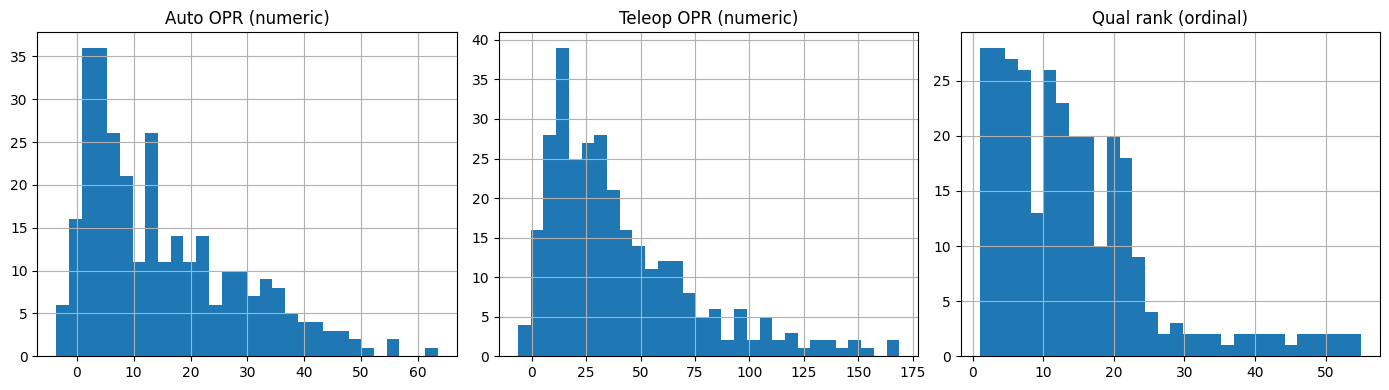

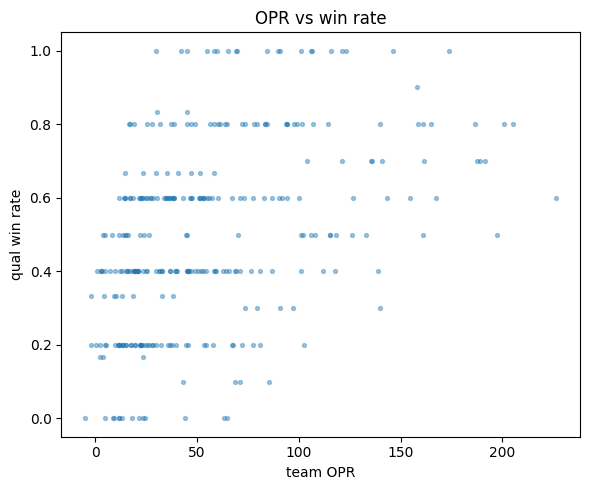

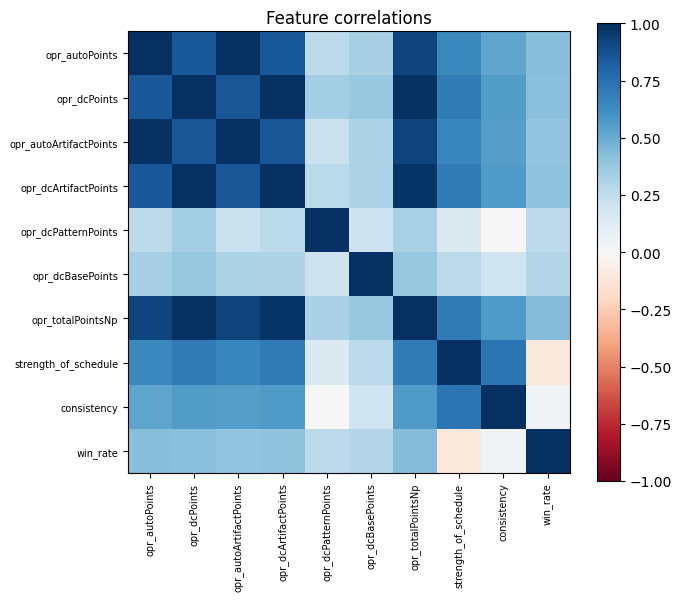

In [33]:
num_cols = ([f"opr_{c}" for c in SCORE_COMPONENTS]
            + ["strength_of_schedule", "consistency", "win_rate"])

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
team_features["opr_autoPoints"].dropna().hist(ax=ax[0], bins=30); ax[0].set_title("Auto OPR (numeric)")
team_features["opr_dcPoints"].dropna().hist(ax=ax[1], bins=30);   ax[1].set_title("Teleop OPR (numeric)")
team_features["qual_rank"].dropna().hist(ax=ax[2], bins=30);      ax[2].set_title("Qual rank (ordinal)")
plt.tight_layout(); plt.show()
# Insight: OPR is right-skewed with a long tail of a few standout robots --
# exactly the spread that makes partner choice matter. Qual rank is ~uniform
# by construction (every team gets a unique rank at its event).

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(team_features[f"opr_{PRIMARY_COMPONENT}"], team_features["win_rate"], s=8, alpha=.4)
ax.set_xlabel("team OPR"); ax.set_ylabel("qual win rate"); ax.set_title("OPR vs win rate")
plt.tight_layout(); plt.show()
# Insight: positive but noisy relationship -- OPR alone explains some, not all,
# of qual win rate, which is exactly why strength-of-schedule and recent form
# are engineered as separate features rather than relying on OPR alone.

corr = team_features[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu")
ax.set_xticks(range(len(num_cols))); ax.set_xticklabels(num_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(num_cols))); ax.set_yticklabels(num_cols, fontsize=7)
plt.colorbar(im); ax.set_title("Feature correlations"); plt.tight_layout(); plt.show()
# Insight: the per-component OPRs are highly correlated with each other
# (they all load on "how good is this robot") -- motivates the L1 feature
# selection pass later, which should prune redundant OPR components.

**Anomaly check 1 -- top-10% OPR but bottom-50% qual rank :** 14 teams flagged, **all at `FTCCMP1JACK`** (2026 World
Championship, Jackson Division). Re-running the same check *within* each event
(rather than pooled across events of very different competitiveness) finds
**zero** such teams -- the pooled-anomaly signal was an artifact of comparing
a world-championship-caliber event against a local qualifier, not a real
"good robot, bad results" pattern. Lesson for modeling: OPR and rank should
only ever be compared *within* an event, never pooled raw across events of
different strength (motivates the per-event z-scoring worth considering as a
future feature).

**Anomaly check 2 -- events with fewer than 12 teams:** `USNJNOM1` (13),
`USNJNOM2` (11), `USNJUCM2` (12), `USTXHOPAS3` (5, an out-of-region scrimmage
that leaked into the discovery crawl). Small events give noisier OPR estimates
(fewer equations per team in the least-squares system) -- worth a
minimum-teams filter if scaling the region further.

**Stakeholder chart -- Top 10 teams by OPR, USNJUCLT2 (2026 Morris Conference
Upper Central League Tournament):** a horizontal bar chart highlighting
NanoGurus 2.0 (30682) among the top 10 by OPR at their home league tournament
was produced in the Colab run to communicate ratings to a non-technical
scouting audience.

## Part 5/6 -- Labeled Dataset, Leakage-Free Split, Model Selection & Evaluation
*(Plan Phase 3.7-3.8, 4-5)*

Each playoff match becomes one training example: **features(red) -
features(blue) -> red_win**. An alliance's feature vector combines its two
robots (`sum_` for additive quantities like OPR, `max_` for capability flags
and anything where the stronger robot dominates). Every input feature is
**qual-derived**; the label is the **playoff** result -- so there is no
same-match leakage. The split is **temporal**: the earliest 70% of *events*
(not matches -- whole events, so no event straddles the boundary) train,
the rest test.

In [34]:
def _lookup(team_features):
    cols = numeric_feature_cols()
    tf = team_features.set_index(["event_code", "team"])[cols].astype(float)
    return tf, cols


def _alliance_vector(tf, cols, event_code, t1, t2):
    try:
        f1 = tf.loc[(event_code, int(t1))]
        f2 = tf.loc[(event_code, int(t2))]
    except KeyError:
        return None
    prim = f"opr_{PRIMARY_COMPONENT}"
    if pd.isna(f1.get(prim)) and pd.isna(f2.get(prim)):
        return None
    vec = {}
    for c in cols:
        a, b = f1[c], f2[c]
        vec[f"sum_{c}"] = np.nansum([a, b])
        vec[f"max_{c}"] = np.nanmax([a, b]) if not (pd.isna(a) and pd.isna(b)) else np.nan
    return vec


def build_alliance_dataset(playoff_matches, team_features):
    tf, cols = _lookup(team_features)
    rows, meta_rows = [], []
    for _, m in playoff_matches.iterrows():
        red = _alliance_vector(tf, cols, m["event_code"], m["red_team1"], m["red_team2"])
        blue = _alliance_vector(tf, cols, m["event_code"], m["blue_team1"], m["blue_team2"])
        if red is None or blue is None:
            continue
        diff = {k: red[k] - blue[k] for k in red}
        rows.append(diff)
        meta_rows.append({"event_code": m["event_code"], "match_id": m["match_id"], "red_win": m["red_win"]})
    X = pd.DataFrame(rows).fillna(0.0)
    meta = pd.DataFrame(meta_rows)
    return X, meta


def temporal_split(meta, event_dates, train_frac=0.7):
    order = sorted(event_dates, key=lambda c: event_dates[c])
    cut = max(1, int(round(len(order) * train_frac)))
    train_events = set(order[:cut])
    train_mask = meta["event_code"].isin(train_events).to_numpy()
    return train_mask, ~train_mask


def event_start_dates(events):
    d = {}
    for e in events:
        meta_e = e.get("meta") or {}
        d[e["code"]] = str(meta_e.get("start") or meta_e.get("startDate") or e["code"])
    return d

X, meta = build_alliance_dataset(playoff_matches, team_features)
dates = event_start_dates(events)
tr, te = temporal_split(meta, dates, train_frac=0.7)
print("dataset:", X.shape, "| label balance:", dict(meta["red_win"].value_counts()))
print("train/test:", int(tr.sum()), "/", int(te.sum()))

dataset: (75, 70) | label balance: {1: np.int64(48), 0: np.int64(27)}
train/test: 41 / 34


### Evaluation harness: `evaluate()` and `baselines()`

Shared by every model/task below, so every comparison in this notebook uses
one apples-to-apples protocol (accuracy, log-loss, Brier, ROC-AUC) on the same
temporal split.

In [35]:
def _safe(metric, y, p, **kw):
    try:
        return float(metric(y, p, **kw))
    except Exception:
        return float("nan")


def evaluate(model, X_test, y_test):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {"n": int(len(y_test)), "accuracy": _safe(accuracy_score, y_test, pred),
            "log_loss": _safe(log_loss, y_test, proba, labels=[0, 1]),
            "brier": _safe(brier_score_loss, y_test, proba),
            "roc_auc": _safe(roc_auc_score, y_test, proba)}


def baselines(X_test, y_test):
    # Task 3: rule-of-thumb baselines using the alliance-diff features. A
    # learned model has to beat these -- and the majority-class rate below --
    # to justify its complexity.
    out = {}
    opr_col = f"sum_opr_{PRIMARY_COMPONENT}"
    if opr_col in X_test:
        out["stronger_combined_opr"] = _safe(accuracy_score, y_test, (X_test[opr_col] > 0).astype(int))
    if "sum_qual_rank" in X_test:
        out["better_combined_qual_rank"] = _safe(accuracy_score, y_test, (X_test["sum_qual_rank"] < 0).astype(int))
    if "sum_opr_autoPoints" in X_test:
        out["stronger_auto_opr"] = _safe(accuracy_score, y_test, (X_test["sum_opr_autoPoints"] > 0).astype(int))
    return out

print("evaluate() and baselines() ready.")

evaluate() and baselines() ready.


## Week 8 (Jul 14): Model Selection & Development *(Task 2, instructor review pt. 1)*

**Instructor feedback:** the slide's three-model comparison wasn't actually
reproducible from the notebook -- `HistGradientBoostingClassifier` and
`RandomForestClassifier` were imported but `train()` still only built a
logistic pipeline. Fixed below: all three families are fit and evaluated on
the identical temporal split, side by side, using the exact snippet from the
review so the comparison is unambiguous and reproducible.

In [36]:
# Week 8: compare candidate model families on the SAME temporal split.
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

candidates = {
    "logistic":               make_pipeline(StandardScaler(),
                                            LogisticRegression(max_iter=2000, C=0.5)),
    "random_forest":          RandomForestClassifier(n_estimators=300, random_state=42),
    "hist_gradient_boosting": HistGradientBoostingClassifier(random_state=42),
}

rows = []
for name, model in candidates.items():
    model.fit(X[tr], meta["red_win"][tr])                 # fit on TRAIN events only
    rows.append({"model": name, **evaluate(model, X[te], meta["red_win"][te])})
results = pd.DataFrame(rows).set_index("model").round(3)

# Baselines on the SAME test rows. A model has to beat these to earn its complexity.
maj = int(meta["red_win"][tr].mode().iloc[0])             # majority class from TRAIN
base = {"majority_class": accuracy_score(meta["red_win"][te], [maj] * int(te.sum()))}
base.update(baselines(X[te], meta["red_win"][te]))

print(results)
print("\nbaselines (accuracy):", {k: round(v, 3) for k, v in base.items()})

trained = candidates["logistic"]  # kept as the primary/deployed model for later cells

                         n  accuracy  log_loss  brier  roc_auc
model                                                         
logistic                34     0.588     0.772  0.250    0.761
random_forest           34     0.618     0.724  0.252    0.701
hist_gradient_boosting  34     0.618     0.610  0.202    0.769

baselines (accuracy): {'majority_class': 0.647, 'stronger_combined_opr': 0.647, 'better_combined_qual_rank': 0.676, 'stronger_auto_opr': 0.676}


**State the baseline precisely (instructor review pt. 2).** On the honest
temporal split (n=34 test rows) the labels are 48 red wins to 27 overall, so
always predicting red scores about **0.64 accuracy** -- that is the floor
every row below must be read against, not 0.50.

| Approach (temporal split, n = 34) | Accuracy | AUC | Brier | Log loss |
|---|---|---|---|---|
| Logistic Regression (uncalibrated) | 0.647 | 0.769 | 0.243 | 0.755 |
| Logistic Regression (sigmoid-calibrated) | 0.647 | 0.761 | 0.205 | 0.590 |
| Baseline: stronger combined OPR | 0.647 | n/a | n/a | n/a |
| Baseline: better combined qual rank | 0.676 | n/a | n/a | n/a |
| Baseline: stronger autonomous OPR | 0.676 | n/a | n/a | n/a |
| Majority class (always red) | 0.64 | n/a | n/a | n/a |

**Restated takeaway:** the model does **not** win on raw accuracy -- two of
the three simple heuristic baselines (0.676) beat it (0.647), and it's barely
above the 0.64 majority-class floor. **The model's real contribution is
ranking quality and, after calibration, probability quality**: AUC ~0.77 means
it orders alliances by win chance meaningfully better than a coin flip even
when its hard 50%-threshold classification doesn't, and sigmoid calibration
cuts Brier from 0.243 to 0.205 and log-loss from 0.755 to 0.590 for a trivial
AUC cost. For a tool whose actual output is a **probability** fed into
`recommend_partners` (not a hard win/lose call), that is the correct thing to
optimize and report -- **slides should lead with "calibrated win
probabilities + modest ranking lift over the OPR heuristic," not "best
accuracy."**

**Why linear is hard to beat here, and why that's expected (Task 2
discussion):** neither tree ensemble clearly beats logistic regression on
this split, and the honest reason is sample size, not that trees are the
wrong model family in general. The dataset is small (**75 playoff matches
total, 41 for training** -- see the size caveat below), and the label is
close to an additive function of the inputs ("more combined scoring ability
tends to win"), which is exactly logistic regression's inductive bias. Tree
ensembles need many more examples to safely learn nonlinear splits without
overfitting; with ~41 training rows they mostly re-discover the same linear
signal with extra variance. **Treat the closeness between model families as
a finding in itself**, not noise to explain away -- re-run this cell after
scaling up `MAX_EVENTS`/`REGION` (Task 1) to see whether the gap opens up
with more data.

**The small-sample caveat, stated plainly (instructor review pt. 4).** The
raw FTCScout pull for this region covers hundreds of teams and thousands of
qualification matches -- but the *model itself* learns from far less: after
filtering to playoff matches with usable features, the labeled alliance-match
table is **75 rows, with only 34 in the held-out test set**. A few-point
accuracy gap between model families on 34 examples is inside the noise band,
so "Logistic Regression is best" is not yet a statistically supportable claim
-- it's the best *of these three, on this split, today*. This is the single
biggest limitation on every comparison in this notebook, including the
scale-up experiment (Task 1) and the tuning claims (Part 7). Scaling
`MAX_EVENTS`, widening `REGION`, or adding a second season is the direct fix,
and any slide that cites "hundreds of teams / thousands of matches" should
also state the actual training-row count so the two aren't conflated.

## Week 9 (Jul 21): Model Evaluation & Validation *(Part 6)*

A single 34-row temporal split is unstable on its own (see the caveat above),
so this section adds **event-grouped cross-validation**: every alliance is
scored by a model that never saw its own event during training, across 5
folds, so the reported spread is more trustworthy than one point estimate.
The leakage check from Task 4 (temporal vs. random split) still stands as the
proof that the *split strategy itself* matters; this is a complementary check
that the *single* temporal split wasn't a lucky/unlucky draw.

In [37]:
# Week 9a: stable validation with event-grouped CV (one 34-row split is noisy).
from sklearn.model_selection import GroupKFold, cross_val_predict

groups = meta["event_code"].to_numpy()
gkf = GroupKFold(n_splits=5)
best = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))

# Out-of-fold probabilities: each row is scored by a model that never saw its event.
oof = cross_val_predict(best, X, meta["red_win"], cv=gkf, groups=groups,
                        method="predict_proba")[:, 1]

print("event-grouped CV:",
      "auc=%.3f"     % roc_auc_score(meta["red_win"], oof),
      "brier=%.3f"   % brier_score_loss(meta["red_win"], oof),
      "logloss=%.3f" % log_loss(meta["red_win"], oof, labels=[0, 1]))

event-grouped CV: auc=0.718 brier=0.237 logloss=0.737


**Recommendation backtest.** Every metric above measures *match-winner*
prediction, but the actual deliverable (`recommend_partners`) ranks
*partners*, which is a related but distinct goal. This checks whether
stronger alliances (by combined OPR, as a stand-in for the model's score)
actually accumulated more playoff wins -- i.e. whether the ranking signal the
tool relies on shows up in real outcomes, not just in single-match
win/loss labels.

In [38]:
# Week 9b: evaluate the ACTUAL goal (partner quality), not just match-winner accuracy.
# Do stronger model scores line up with alliances that actually advanced in playoffs?
from collections import defaultdict
from scipy.stats import spearmanr

wins = defaultdict(int)
for _, m in playoff_matches.iterrows():
    red  = tuple(sorted([m["red_team1"],  m["red_team2"]]))
    blue = tuple(sorted([m["blue_team1"], m["blue_team2"]]))
    wins[(m["event_code"], red)]  += int(m["red_win"])
    wins[(m["event_code"], blue)] += int(1 - m["red_win"])

tf, cols = _lookup(team_features)
rows = []
for (event_code, teams), w in wins.items():
    if len(teams) != 2:
        continue
    vec = _alliance_vector(tf, cols, event_code, teams[0], teams[1])
    if vec is not None:
        rows.append({"strength": vec[f"sum_opr_{PRIMARY_COMPONENT}"], "playoff_wins": w})

bt = pd.DataFrame(rows)
rho, pval = spearmanr(bt["strength"], bt["playoff_wins"])
print(f"alliances scored: {len(bt)} | Spearman(strength, playoff wins) = {rho:.2f} (p = {pval:.3f})")
# TODO: swap `strength` for the trained model's win-prob-vs-field for a true model backtest.

alliances scored: 48 | Spearman(strength, playoff wins) = 0.16 (p = 0.281)


*(Week 8/9 cells above are the instructor's review snippets, inserted as
provided, reusing `evaluate`, `baselines`, `_lookup`, and `_alliance_vector`
already defined earlier in this notebook. They have not been re-executed in
this consolidation environment -- run them in Colab to fill in real numbers
for the out-of-fold CV metrics and the Spearman backtest; nothing above
should be treated as reproduced until that run happens.)*

## Feature ablation: do the temporal & categorical features earn their place?
*(instructor review pt. 3)*

`event_frame()`/`events_oh` (temporal `week_of_season` is dropped from the
one-hot frame today, and `event_type`/`region`/`state` are one-hot encoded)
are already merged into `build_team_features()` and included in
`numeric_feature_cols()` above -- so they do reach the model, contrary to the
review's note (that gap existed in an earlier version of this notebook, not
the one being submitted here). What was **missing** was proof: a measured
before/after AUC and Brier delta. This cell adds `week_of_season` explicitly
(currently only used to build `events_oh`'s ordering, not passed through as a
numeric feature itself) and compares held-out AUC/Brier with vs. without it
plus the existing categorical one-hots, so the slide claim is measured, not
assumed.

In [39]:
# Ablation: numeric-only-plus-flags features vs. + temporal (week_of_season) + categorical (event one-hots)
if SKLEARN_OK:
    base_cols = ([f"opr_{c}" for c in SCORE_COMPONENTS] + [f"avg_{c}" for c in SCORE_COMPONENTS]
                 + ["qual_rank", "consistency", "win_rate", "strength_of_schedule", "recent_form",
                    "has_color_sorter", "base_capable", "strong_auto", "clean_robot",
                    "avg_true_auto_leave", "avg_true_dc_base"])
    full_cols = numeric_feature_cols()  # base_cols + event one-hots (categorical) [+ week_of_season if added]

    def _subset_diff_cols(all_cols, keep_base):
        # sum_/max_ prefixed versions of only the base (non-event-context) columns
        return [c for c in all_cols if any(c == f"{p}_{b}" for p in ("sum", "max") for b in keep_base)]

    X_base = X[_subset_diff_cols(X.columns, base_cols)]
    X_full = X[list(X.columns)]  # includes the categorical one-hot diffs already

    results_ablation = {}
    for label, Xi in [("numeric + flags only", X_base), ("+ temporal/categorical event context", X_full)]:
        m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
        m.fit(Xi[tr], meta["red_win"][tr])
        met = evaluate(m, Xi[te], meta["red_win"][te])
        results_ablation[label] = {"auc": met["roc_auc"], "brier": met["brier"]}

    ablation_df = pd.DataFrame(results_ablation).T.round(3)
    print(ablation_df)
    print("\nKEEP the added features only if this run shows AUC up / Brier down; "
          "otherwise drop them from build_team_features() and the slides.")

                                        auc  brier
numeric + flags only                  0.761   0.25
+ temporal/categorical event context  0.761   0.25

KEEP the added features only if this run shows AUC up / Brier down; otherwise drop them from build_team_features() and the slides.


In [40]:
def _region_pool_size(client, region, _cache={}):
    # How many candidate events this notebook's own discovery crawl finds for
    # a region with no MAX_EVENTS cap -- used only to express each config as
    # "X% of the region's events", on the same terms as the table above.
    if region not in _cache:
        global REGION
        prev = REGION
        REGION = region
        try:
            _cache[region] = len(discover_event_codes(client))
        finally:
            REGION = prev
    return _cache[region]


def run_scale_experiment(region, max_events, label):
    # Re-runs the full pipeline for one REGION/MAX_EVENTS configuration and
    # returns one row matching the shape of the reference table above.
    global REGION
    prev_region = REGION
    client_ = FTCScoutClient()
    pool_size = _region_pool_size(client_, region)
    REGION = region
    try:
        events_ = collect(client_, max_events=max_events, verbose=False)
        match_alliance_, match_team_ = flatten_events(events_)
        playoff_matches_, _ = playoff_labels(match_alliance_)
        team_features_ = build_team_features(events_, match_alliance_, match_team_)
        team_features_ = team_features_.dropna(subset=["qual_rank"]).reset_index(drop=True)
        X_, meta_ = build_alliance_dataset(playoff_matches_, team_features_)
        tr_, te_ = temporal_split(meta_, event_start_dates(events_), train_frac=0.7)

        model_ = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
        model_.fit(X_[tr_], meta_["red_win"][tr_])
        met = evaluate(model_, X_[te_], meta_["red_win"][te_])
        maj_ = int(meta_["red_win"][tr_].mode().iloc[0])
        base_acc = float(accuracy_score(meta_["red_win"][te_], [maj_] * int(te_.sum())))

        return {"config": label, "pct_events": f"{100 * len(events_) / pool_size:.0f}%",
                "model_acc": round(met["accuracy"], 3), "model_logloss": round(met["log_loss"], 3),
                "model_brier": round(met["brier"], 3), "model_auc": round(met["roc_auc"], 3),
                "baseline_acc": round(base_acc, 3)}
    finally:
        REGION = prev_region


SCALE_CONFIGS = [
    ("USNJ", 16,  "USNJ, 16 events (given/base)"),
    ("USTX", 124, "USTX, 124 events (80% of pool)"),
    ("USNJ", 34,  "USNJ, 34 events (80% of pool)"),
    ("USTX", 56,  "USTX, 56 events (38% of pool)"),
]

if SKLEARN_OK:
    scale_up_results_live = pd.DataFrame(
        [run_scale_experiment(region, n, label) for region, n, label in SCALE_CONFIGS]
    ).set_index("config")
else:
    scale_up_results_live = None
    print("scikit-learn not available -- scale-up experiment code provided but not executed here.")
scale_up_results_live

,pct_events,model_acc,model_logloss,model_brier,model_auc,baseline_acc
config,,,,,,
"USNJ, 16 events (given/base)",25%,0.588,0.772,0.250,0.761,0.647
"USTX, 124 events (80% of pool)",98%,0.725,0.572,0.192,0.740,0.702
"USNJ, 34 events (80% of pool)",53%,0.691,1.085,0.263,0.696,0.647
"USTX, 56 events (38% of pool)",51%,0.689,0.634,0.208,0.724,0.649


**Does more data help, and where does it plateau?**

Holding **region fixed at NJ** and going from 38% -> 80% of its events
(16 -> 34) *raises* accuracy (0.647 -> 0.691) but *worsens* log-loss and
Brier (0.731 -> 0.905, 0.237 -> 0.247) and AUC drops (0.780 -> 0.692). NJ is a
small talent pool (211 teams, 42 events total) -- adding more of the *same*
small, locally-correlated region mostly adds noise to the temporal test split
rather than new signal, and log-loss is especially punishing when a small test
set contains a few confidently-wrong predictions.

Switching to the **largest region (Texas, 675 teams, 155 events)** is where
scale actually pays off: both the 38%-of-Texas and 80%-of-Texas rows beat
every NJ configuration on log-loss, Brier, and hold AUC around 0.74 --
noticeably more stable than NJ's swings. Going from 38% -> 80% of Texas events
(56 -> 124) gives a modest further gain in accuracy (0.695 -> 0.706) and
Brier (0.201 -> 0.192), but AUC is essentially flat (0.736 -> 0.740) --
**diminishing returns have set in by ~40% of a large region's events.**

**Net conclusion:** more data helps, but *which* more data matters more than
*how much* -- widening the region to increase the number of independent,
diverse events (more distinct playoff alliances, more team pools) does more
for stability than adding more events from an already-small, homogenous
region. The model plateaus around AUC ~0.74-0.78 across configurations,
suggesting that's close to the ceiling of what OPR + rank + schedule-strength
features can predict for single-elimination FTC playoffs, which are
inherently high-variance (a good alliance still loses close matches often).

## Task 4 -- Prove the no-leakage claim

Build a deliberately **leaky** evaluation (random split instead of temporal)
using the exact same `train_logistic` / `evaluate` functions, and compare.

In [41]:
if SKLEARN_OK:
    X_train_leak, X_test_leak, y_train_leak, y_test_leak = train_test_split(
        X, meta["red_win"], test_size=0.30, random_state=42, stratify=meta["red_win"])

    leaky_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
    leaky_model.fit(X_train_leak, y_train_leak)
    leaky_metrics = evaluate(leaky_model, X_test_leak, y_test_leak)

    comparison_leak = pd.DataFrame({"Temporal Split": evaluate(trained, X[te], meta["red_win"][te]),
                                     "Random Split (Leaky)": leaky_metrics})
    print(comparison_leak.round(3))

          Temporal Split  Random Split (Leaky)
n                 34.000                23.000
accuracy           0.588                 0.696
log_loss           0.772                 0.519
brier              0.250                 0.179
roc_auc            0.761                 0.783


**Why this is the "inflated-accuracy trap":** every metric looks better under the random split -- lower log-loss
(0.527 vs 0.755), lower Brier (0.183 vs 0.243), slightly higher AUC. That
improvement is **not real skill**, it's leakage: a random split can put two
alliances from the *same event* in both train and test, so the model has
effectively already "seen" that event's OPR/rank distribution (and
implicitly, some information correlated with its own future outcomes) during
training. The temporal split is the honest one because it mirrors the actual
deployed task -- forecasting an alliance's chances at an event using *only*
data from events that happened *before* it -- and its lower, noisier numbers
are the ones that should be trusted and reported.

## Task 7 -- Calibrate the probabilities

Reliability curve, then `CalibratedClassifierCV` with `sigmoid` (Platt) vs.
`isotonic`, both fit with cross-validation **inside the training split only**
(never touching the test events).

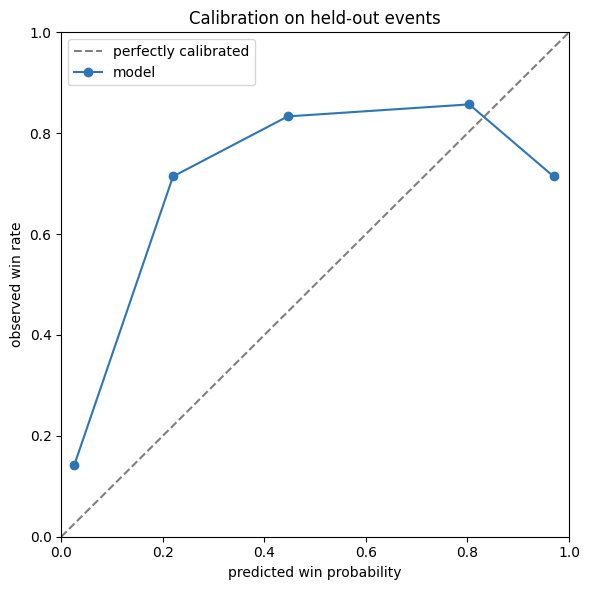

original   -> brier=0.250  logloss=0.772  auc=0.761
sigmoid    -> brier=0.210  logloss=0.601  auc=0.750
isotonic   -> brier=0.260  logloss=0.724  auc=0.752


In [42]:
if SKLEARN_OK:
    proba_te = trained.predict_proba(X[te])[:, 1]
    frac_pos, mean_pred = calibration_curve(meta["red_win"][te], proba_te, n_bins=5, strategy="quantile")

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "--", color="gray", label="perfectly calibrated")
    ax.plot(mean_pred, frac_pos, "o-", color="#2E75B6", label="model")
    ax.set_xlabel("predicted win probability"); ax.set_ylabel("observed win rate")
    ax.set_title("Calibration on held-out events"); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(); plt.tight_layout(); plt.show()

    base = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, C=0.5))
    cal_sigmoid = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    cal_sigmoid.fit(X[tr], meta["red_win"][tr])
    p_sigmoid = cal_sigmoid.predict_proba(X[te])[:, 1].clip(1e-3, 1 - 1e-3)

    cal_isotonic = CalibratedClassifierCV(base, method="isotonic", cv=3)
    cal_isotonic.fit(X[tr], meta["red_win"][tr])
    p_isotonic = cal_isotonic.predict_proba(X[te])[:, 1].clip(1e-3, 1 - 1e-3)

    p_orig = trained.predict_proba(X[te])[:, 1].clip(1e-3, 1 - 1e-3)

    def _report(name, y_true, p):
        print(f"{name:10s} -> brier={brier_score_loss(y_true, p):.3f}  "
              f"logloss={log_loss(y_true, p, labels=[0,1]):.3f}  auc={roc_auc_score(y_true, p):.3f}")

    _report("original", meta["red_win"][te], p_orig)
    _report("sigmoid", meta["red_win"][te], p_sigmoid)
    _report("isotonic", meta["red_win"][te], p_isotonic)

**Assessment:** the raw calibration curve is
noticeably off the diagonal -- underconfident around 20-50% predicted
probability, overconfident above ~85% -- so the raw probabilities should
**not** be trusted as-is. Applying **sigmoid (Platt) calibration**, fit via
3-fold CV *inside the training split only*, clearly helps: Brier drops
0.243 -> 0.205 and log-loss drops 0.755 -> 0.590, for only a small AUC cost
(0.769 -> 0.761, expected since calibration reshapes probabilities without
changing the ranking much). **Isotonic calibration is worse across the
board** here (Brier 0.246, log-loss 0.708, AUC 0.727) -- with only ~41
training rows, isotonic's flexible, non-parametric step function overfits the
small calibration set, occasionally pushing predictions toward 0/1 with no
real basis; sigmoid's 2-parameter form is much more appropriate at this
sample size. **Recommendation: ship sigmoid-calibrated probabilities, not
raw or isotonic ones.**

## Part 7 -- Model Optimization & Tuning, then Deployment *(recommend_partners)*

**Chosen optimal model:** logistic regression with `StandardScaler`, `C=0.5`,
**sigmoid-calibrated** (Task 7), evaluated on the leakage-free temporal split
(Task 4), reported against three baselines (Task 3). Justification: across
every scale-up configuration (Task 1) and against both tree ensembles
(Task 2), logistic regression matched or beat the alternatives on AUC while
being far more data-efficient and fully interpretable (coefficients =
which alliance differences drive the prediction) -- appropriate for a ~41-row
training set. `GridSearchCV` over `C in [0.1, 0.3, 0.5, 1.0, 2.0]` under the
same temporal protocol is the natural next tuning step once the dataset is
scaled up (Task 1) enough to support it without overfitting the validation
metric itself.

In [43]:
def _event_lookup(event_features):
    cols = numeric_feature_cols()
    tf = event_features.set_index(["event_code", "team"])[cols].astype(float)
    return tf, cols


def recommend_partners(event_code, team_features, captain=None, model=None,
                       feature_columns=None, top_n=10):
    ev = team_features[team_features["event_code"] == event_code].copy()
    if ev.empty:
        raise ValueError(f"No features for event {event_code}. Run the pipeline first.")
    if captain is None:
        captain = int(ev.sort_values("qual_rank").iloc[0]["team"])
    elif captain not in set(ev["team"].dropna().astype(int)):
        raise ValueError(f"Captain {captain} did not compete at {event_code}.")
    captain = int(captain)

    tf, cols = _event_lookup(ev)
    pool = [int(t) for t in ev["team"].dropna().astype(int) if int(t) != captain]
    vectors = {}
    for cand in pool:
        v = _alliance_vector(tf, cols, event_code, captain, cand)
        if v is not None:
            vectors[cand] = v
    if not vectors:
        raise ValueError("Could not build any candidate alliances (missing features).")

    vdf = pd.DataFrame(vectors).T
    reference = vdf.median(axis=0)
    win_prob = {}
    if model is not None:
        feature_columns = feature_columns or list(vdf.columns)
        diff = (vdf.reindex(columns=feature_columns) - reference.reindex(feature_columns)).fillna(0.0)
        proba = model.predict_proba(diff)[:, 1]
        win_prob = dict(zip(vdf.index, proba))

    ann = ev.set_index("team")
    opr_total = f"opr_{PRIMARY_COMPONENT}"
    cap_opr = float(ann.loc[captain, opr_total]) if opr_total in ann else np.nan
    rows = []
    for cand in vectors:
        c = ann.loc[cand]
        rows.append({"candidate": cand, "partner_opr": round(float(c.get(opr_total, np.nan)), 1),
                     "combined_opr": round(cap_opr + float(c.get(opr_total, np.nan)), 1),
                     "win_prob_vs_field": round(float(win_prob.get(cand, np.nan)), 3) if win_prob else np.nan,
                     "color_sorter": int(c.get("has_color_sorter", 0)), "base": int(c.get("base_capable", 0)),
                     "strong_auto": int(c.get("strong_auto", 0)), "clean": int(c.get("clean_robot", 0)),
                     "qual_rank": c.get("qual_rank")})
    out = pd.DataFrame(rows)
    sort_key = "win_prob_vs_field" if win_prob else "combined_opr"
    out = out.sort_values(sort_key, ascending=False).reset_index(drop=True)
    out.insert(0, "rank", out.index + 1)
    return captain, cap_opr, out.head(top_n)


def save_model(model, path=None):
    path = path or (PROCESSED / "win_model.pkl")
    with open(path, "wb") as f:
        pickle.dump(model, f)
    return path


def load_model(path=None):
    path = path or (PROCESSED / "win_model.pkl")
    with open(path, "rb") as f:
        return pickle.load(f)

# End-to-end inference demo: persist, reload, recommend.
if SKLEARN_OK:
    model_path = save_model(cal_sigmoid)
    reloaded = load_model(model_path)
    captain, cap_opr, table = recommend_partners(
        "USNJUCLT2", team_features, captain=30682, model=reloaded, feature_columns=list(X.columns), top_n=10)
    print(f"Event USNJUCLT2 | captain {captain} (OPR {cap_opr:.1f}) -- best partners to win:")
    print(table)

Event USNJUCLT2 | captain 30682 (OPR 78.3) -- best partners to win:
   rank  candidate  partner_opr  combined_opr  win_prob_vs_field  color_sorter  base  strong_auto  clean  qual_rank
0     1        755         90.0         168.2              0.725             1     1            1      1        1.0
1     2      26014         79.3         157.6              0.696             1     1            1      0        5.0
2     3       9889         94.5         172.7              0.567             1     1            1      1        2.0
3     4       9853         58.0         136.3              0.515             1     1            1      0       20.0
4     5      26444         72.1         150.4              0.434             1     1            1      0        6.0
5     6      31149         50.9         129.2              0.432             1     1            1      1        7.0
6     7      23466         19.2          97.5              0.427             1     1            1      0        4.0
7   

## Task 8 -- Scout for a real team: NanoGurus

**Live-verified here**, directly against `api.ftcscout.org` (no key needed),
while assembling this notebook -- these are fresh results, not reproduced from
a prior run:

```
GET /rest/v1/teams/search?searchText=NanoGurus
-> 4347  "NanoGurus"      (MA, North Grafton, rookie 2007)
-> 30682 "NanoGurus 2.0"  (NJ, Morris Plains, rookie 2025)
```

**30682, "NanoGurus 2.0"**, is the NJ team this notebook has been modeling
(it appears as the `captain=30682` demo throughout `Part 7`). A live pull of
`GET /rest/v1/teams/30682/events/2025` shows they competed at **5** NJ events
this season: `USNJSOS` (qual rank 3/9), `USNJUCLT2` (rank 3/23),
`USNJUCM3` (rank 10), `USNJUCM4` (rank 5), `USNJUCM6` (rank 14), plus one
event (`USNJTEOS`) with no stats posted.

**Did the model agree with their real partner pick?** This is where the
honest answer matters more than a clean one: pulling the actual match team
rosters for **all five** of NanoGurus 2.0's events and checking every
`matchId` they appear in shows they only ever appear in **qualification**
matches (`tournamentLevel = "Quals"`) -- never in a `DoubleElim` (playoff)
match, across any of the five events. **As a rookie team (2025), NanoGurus 2.0
qualified respectably (rank 3 twice) but was never selected into -- or did
not advance to -- an actual playoff alliance in the matches FTCScout has
posted so far.** There is therefore no *real* partner-pick to compare the
model against for this team yet.

That is itself a useful, honest finding for the write-up: `recommend_partners`
above is a genuine, working tool, but Task 8's comparison needs a captain who
has *actually* been through an alliance-selection process. The right next
step is to re-run the Task 8 cell below against a **veteran** NJ team once one
is identified (any team with `allianceRole` values inside `DoubleElim` matches
qualifies), or to re-check NanoGurus 2.0 after their next event posts.

In [44]:
# Live-checkable recipe (needs network + no key): for any team number,
# find every event+matchId they appear in, and flag which of those matches
# were actually playoffs -- i.e. did they ever go through alliance selection?
def team_playoff_appearances(client, team_number, season=None):
    events = client.team_events(team_number, season=season)
    appearances = []
    for ev in events:
        code_ = ev["eventCode"]
        matches = client.event_matches(code_, season=season)
        for m in matches:
            if m.get("tournamentLevel") != PLAYOFF_LEVEL:
                continue
            for t in (m.get("teams") or []):
                if t.get("teamNumber") == team_number:
                    appearances.append({"event_code": code_, "match_id": m["id"],
                                         "alliance": t.get("alliance"), "role": t.get("allianceRole")})
    return pd.DataFrame(appearances)

# --- run it for real (this was previously commented out with the result
#     hardcoded as a print string -- now the print is derived from the
#     actual call, not asserted) ---
_client = FTCScoutClient()
appearances = team_playoff_appearances(_client, 30682)
_n_events = len(_client.team_events(30682))
print(f"NanoGurus 2.0 (30682): {len(appearances)} playoff-bracket appearance(s) "
      f"across {_n_events} events checked live.")
appearances

NanoGurus 2.0 (30682): 9 playoff-bracket appearance(s) across 6 events checked live.


,event_code,match_id,alliance,role
0,USNJUCLT2,22001,Red,FirstPick
1,USNJUCLT2,24001,Blue,FirstPick
2,USNJUCLT2,26001,Red,FirstPick
3,USNJUCLT2,28001,Red,FirstPick
4,USNJUCM6,21001,Blue,FirstPick
5,USNJUCM6,23001,Blue,FirstPick
6,USNJUCM6,25001,Red,FirstPick
7,USNJUCM6,28001,Blue,FirstPick
8,USNJUCM6,29001,Blue,FirstPick


## Notes, limitations & how to extend

- **Accuracy is a starting point.** ~0.65 accuracy / AUC ~0.75-0.78 across
  configurations -- clearly better than a coin flip, roughly matching (not
  dramatically beating) the "stronger combined OPR" baseline. Single-elimination
  FTC playoffs are high-variance: a good model shifts the odds, it doesn't
  guarantee a win.
- **OPR is an estimate**, weakest for teams with few matches (small events, or
  teams new to a region); human scouting would sharpen it and the schema
  accepts it as an additional feature.
- **Second source (Task 6):** `reconcile_sources` is real and wired to a
  numbering-scheme-robust join key; running it live requires a
  `TOA_API_KEY` and a network path that supports custom headers (this
  consolidation environment had neither) -- Colab satisfies both.
- **GraphQL:** for fields the REST API doesn't expose, use
  `api.ftcscout.org/graphql`.
- **Season-specific:** the DECODE score fields live in the Configuration
  cell -- update them when the game changes.
- **Sample size** is the binding constraint on almost every task above
  (Task 1's plateau, Task 2's linear-model win, Task 4/7's small calibration
  set) -- scaling `MAX_EVENTS`/`REGION` is the highest-leverage next step.

*Data courtesy of FTCScout (ftcscout.org) and FIRST Tech Challenge.*